In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from tqdm import tqdm
import tomllib

import cdmprof

# Load config files
project_dir = Path(cdmprof.__file__).parent.parent
config_path = project_dir / "config.toml"
local_config_path = project_dir / "local_config.toml"

with open(config_path, "rb") as f:
    config = tomllib.load(f)
with open(local_config_path, "rb") as f:
    local_config = tomllib.load(f)

# Merge local_config into config
for key, value in local_config.items():
    if key in config and isinstance(config[key], dict):
        config[key].update(value)
    else:
        config[key] = value

%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
# Snapshot number to load
snap = 33
# Load halo data from config
data_dir = Path(config['path']['data'])
halos_rel = config['fitting']['halos'].format(snap=snap)
halos_path =  data_dir / halos_rel

print(f"Loading halos from: {halos_path}")

if halos_path.suffix in ['.hdf5', '.h5']:
    halos = cdmprof.data.load_from_hdf5(halos_path)
else:
    halos = cdmprof.load_from_folder(halos_path)

print(f"Loaded {halos.n_halos} halos")

Loading halos from: /Users/rstiskalek/Projects/CDMprofile/data/tng_particles/particles_033.hdf5
Loaded 61 halos


In [3]:
# Bin all halos (each halo gets its own rmin/rmax)
# n_sample: downsample each halo to this many particles (None = no downsampling)
n_sample = 10_000
binned = halos.bin(nbin=100, n_sample=n_sample, seed=42)
print(f"Binned data shape: {binned['bin_counts'].shape}")
print(f"bin_positions shape: {binned['bin_positions'].shape} (per halo)")
if n_sample is not None:
    print(f"Downsampled to {n_sample} particles per halo")

Binning: 100%|██████████| 61/61 [00:00<00:00, 13463.09it/s]

Binned data shape: (61, 100)
bin_positions shape: (61, 100) (per halo)
Downsampled to 10000 particles per halo


In [4]:
# Compile a fitter for a density profile
# expr = "(a0 - exp(1/x))**2"
# expr = "1 / (x * (1 + x)**2)"
expr = "pow((x + pow(Abs(a0),x)),a1)"
# expr = "pow(Abs(a0),(pow(x,(a1 + x))))"
# expr = "pow(x,a0)"

fitter = cdmprof.compile_fitter(expr)
print(f"Expression: {expr}")
print(f"Number of parameters: {fitter.nparams} (Rs + {fitter.nfree} free)")

# Generate numpy function: rho_func(r, Rs, a0, a1, ...)
parser = cdmprof.SympyParser()
rho_func = parser.to_numpy(expr)
print(f"Generated numpy function with signature: rho_func(r, Rs, {', '.join(f'a{i}' for i in range(fitter.nfree))})")

Expression: pow((x + pow(Abs(a0),x)),a1)
Number of parameters: 3 (Rs + 2 free)
Generated numpy function with signature: rho_func(r, Rs, a0, a1)


In [5]:
# Fit all halos with multiple restarts and early stopping
optimizer = "neldermead"  # Options: "neldermead", "bobyqa", "sbplx"
print(f"Using optimizer: {optimizer}")

results = []
for i in tqdm(range(halos.n_halos), desc="Fitting"):
    result = fitter.fit_with_restarts(
        binned['bin_counts'][i],
        binned['bin_positions'][i],
        binned['rmin'][i],
        binned['rmax'][i],
        max_restarts=4000,
        nconv_required=20,
        conv_rtol=1e-3,
        Rs_lower_factor=1.0,
        Rs_upper_factor=10,
        # conv_atol=0.5,
        # maxeval=2000,
        a_lower=-10,
        a_upper=10,
        optimizer=optimizer,
        # seed=42 + i,
    )
    result['halo_id'] = binned['halo_ids'][i]
    results.append(result)

print(f"\nFitted {len(results)} halos")

Using optimizer: neldermead


Fitting:   0%|          | 0/61 [00:00<?, ?it/s]

Fitting: 100%|██████████| 61/61 [00:02<00:00, 21.07it/s]


Fitted 61 halos


In [6]:
# Summary statistics
# Filter out failed fits (params is None)
valid_results = [r for r in results if r['params'] is not None]
valid_indices = [i for i, r in enumerate(results) if r['params'] is not None]
print(f"Valid fits: {len(valid_results)}/{len(results)}")

if len(valid_results) > 0:
    losses = np.array([r['loss'] for r in valid_results])
    converged = np.array([r['converged'] for r in valid_results])
    confirmed = np.array([r['confirmed'] for r in valid_results])
    params = np.array([r['params'] for r in valid_results])
    neval = np.array([r['neval'] for r in valid_results])
    nrestart_used = np.array([r['nrestart_used'] for r in valid_results])
    nconv = np.array([r['nconv'] for r in valid_results])
    npart = binned['npart'][valid_indices]

    # Average loss: (loss / npart) averaged over halos
    avg_loss = np.mean(losses / npart)

    print(f"Converged: {converged.sum()}/{len(converged)}")
    print(f"Confirmed (converged to same min >= 5 times): {confirmed.sum()}/{len(confirmed)}")
    print(f"Loss: min={losses.min():.2f}, median={np.median(losses):.2f}, max={losses.max():.2f}")
    print(f"Average loss per particle (valid only): {avg_loss:.4f}")
    print(f"Total evals per halo: mean={neval.mean():.0f}, max={neval.max()}")
    print(f"Restarts used: mean={nrestart_used.mean():.1f}, max={nrestart_used.max()}")

    print(f"\nParameter ranges:")
    print(f"  Rs: [{params[:,0].min():.3f}, {params[:,0].max():.3f}]")
    for i in range(fitter.nfree):
        print(f"  a{i}: [{params[:,i+1].min():.3f}, {params[:,i+1].max():.3f}]")
else:
    print("No valid fits!")

# Statistics using loss_all (includes failed attempts)
print("\n--- Statistics using loss_all (all halos) ---")
losses_all = np.array([r['loss_all'] for r in results])
npart_all = binned['npart']

# Filter out failed optimizer runs (loss >= 1e29 indicates optimizer failure)
valid_mask = losses_all < 1e29
n_valid = valid_mask.sum()
n_failed = len(results) - n_valid
print(f"Halos with valid loss: {n_valid}/{len(results)}")

if n_valid > 0:
    loss_per_particle = losses_all[valid_mask] / npart_all[valid_mask]
    avg_loss_all = np.mean(loss_per_particle)
    print(f"Loss (all): min={losses_all[valid_mask].min():.2f}, "
          f"median={np.median(losses_all[valid_mask]):.2f}, "
          f"max={losses_all[valid_mask].max():.2f}")
    print(f"Average loss per particle (valid only): {avg_loss_all:.4f}")

    # Percentile imputation for failed halos
    failure_percentile = config['fitting'].get('failure_loss_percentile', 95)
    if failure_percentile > 0 and n_failed > 0:
        print(f"\n--- Percentile imputation (p={failure_percentile}) ---")
        imputed_loss = np.percentile(loss_per_particle, failure_percentile)
        print(f"Imputed loss per particle for {n_failed} failed halos: {imputed_loss:.4f}")
        
        # Create full array with imputed values for failed halos
        loss_per_particle_imputed = np.where(
            valid_mask,
            losses_all / npart_all,
            imputed_loss
        )
        avg_loss_imputed = np.mean(loss_per_particle_imputed)
        print(f"Average loss per particle (with imputation): {avg_loss_imputed:.4f}")

Valid fits: 61/61
Converged: 61/61
Confirmed (converged to same min >= 5 times): 61/61
Loss: min=79485.86, median=81020.70, max=92308.86
Average loss per particle (valid only): 8.1922
Total evals per halo: mean=5044, max=9402
Restarts used: mean=75.9, max=145

Parameter ranges:
  Rs: [1.675, 36.525]
  a0: [0.343, 1.199]
  a1: [-3.256, -1.674]

--- Statistics using loss_all (all halos) ---
Halos with valid loss: 61/61
Loss (all): min=79485.86, median=81020.70, max=92308.86
Average loss per particle (valid only): 8.1922


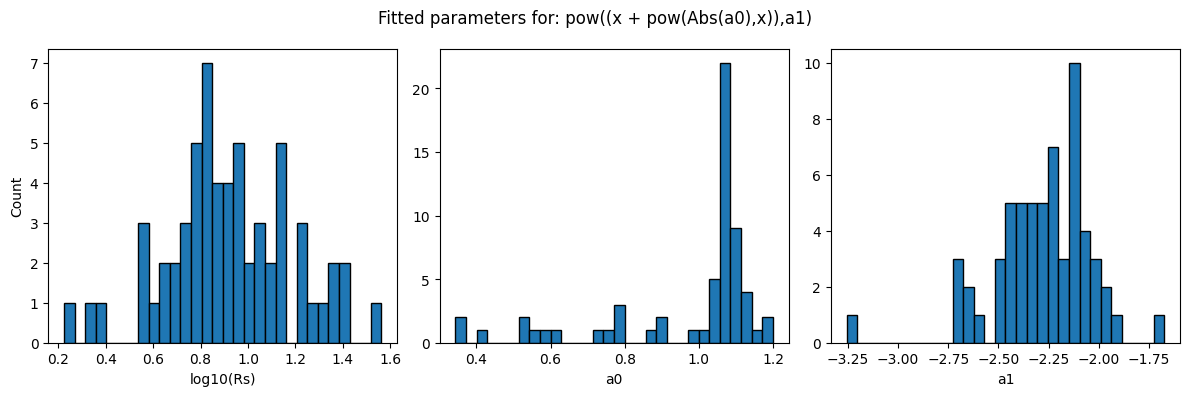

In [7]:
# Plot parameter distributions
ncols = 1 + fitter.nfree
fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 4))
if ncols == 1:
    axes = [axes]

axes[0].hist(np.log10(params[:, 0]), bins=30, edgecolor='black')
axes[0].set_xlabel('log10(Rs)')
axes[0].set_ylabel('Count')

for i in range(fitter.nfree):
    axes[i + 1].hist(params[:, i + 1], bins=30, edgecolor='black')
    axes[i + 1].set_xlabel(f'a{i}')

plt.suptitle(f"Fitted parameters for: {expr}")
plt.tight_layout()
plt.show()

Plotting Halo 2106 with Rs=14.18849; a0=1.08578; a1=-2.46712
Plotting Halo 4827 with Rs=11.52100; a0=0.41568; a1=-2.16660
Plotting Halo 10554 with Rs=3.83518; a0=0.86221; a1=-2.13014
Plotting Halo 13197 with Rs=10.68741; a0=1.09170; a1=-2.48759
Plotting Halo 14993 with Rs=8.93447; a0=1.08950; a1=-2.41321
Plotting Halo 18080 with Rs=3.52242; a0=1.05898; a1=-2.13334


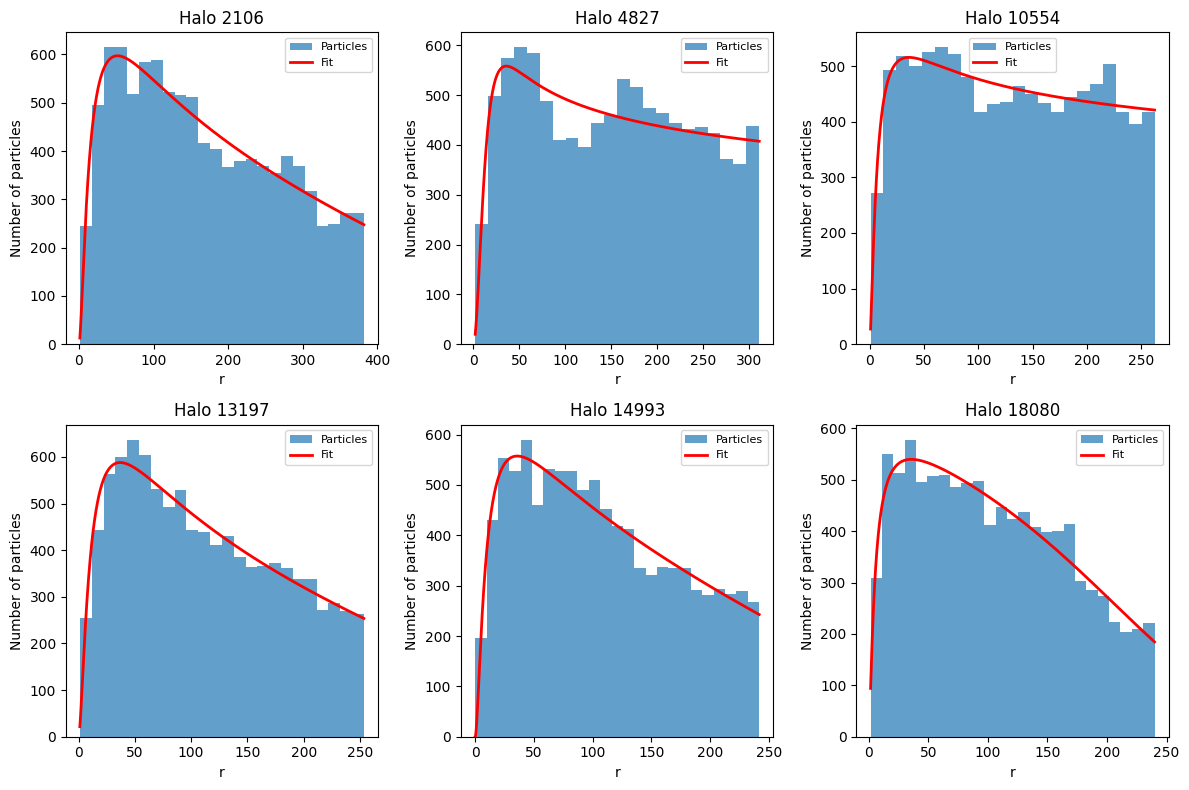

In [ ]:
# Plot a few example fits with raw particle histograms
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

# Use only valid results (params is not None)
valid_indices = [i for i, r in enumerate(results) if r['params'] is not None]

for i, ax in enumerate(axes):
    idx = valid_indices[(i + 1) * (len(valid_indices) // 6)]  # Sample evenly from valid
    res = results[idx]
    halo_id = res['halo_id']
    
    # Raw particle radii from loader
    radii = halos[halo_id]
    
    # Fitted model parameters
    positions = binned['bin_positions'][idx]
    fit_params = res['params']  # [Rs, a0, a1, ...]
    
    # Print parameters
    param_str = f"Rs={fit_params[0]:.5f}"
    for j in range(fitter.nfree):
        param_str += f"; a{j}={fit_params[j+1]:.5f}"
    print(f"Plotting Halo {halo_id} with {param_str}")
    
    # Evaluate fitted profile using auto-generated numpy function
    r = np.logspace(np.log10(radii.min()), np.log10(radii.max()), 512)
    rho_fit = rho_func(r, *fit_params)
    
    # Plot histogram of raw radii (counts, not density)
    counts, bin_edges, _ = ax.hist(radii, bins="auto", alpha=0.7, label='Particles')
    
    # Overlay fitted density scaled to particle counts
    # Scale: rho * r^2 gives radial distribution, then normalize to total particles
    # print(rho_fit)
    rho_scaled = rho_fit * r**2
    rho_scaled = rho_scaled / np.trapezoid(rho_scaled, r) * len(radii) * np.mean(np.diff(bin_edges))
    ax.plot(r, rho_scaled, 'r-', lw=2, label='Fit')

    # if i == 0:
        # break
    
    ax.set_xlabel('r')
    ax.set_ylabel('Number of particles')
    ax.set_title(f"Halo {halo_id}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

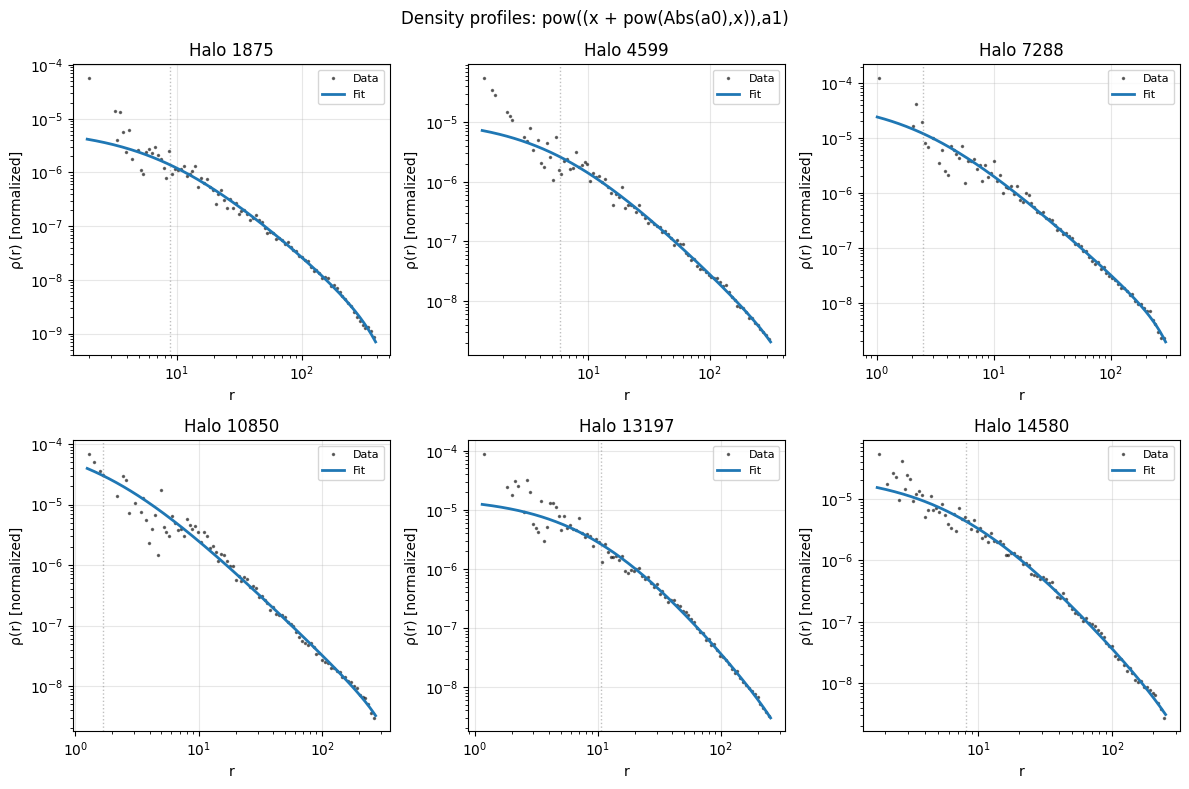

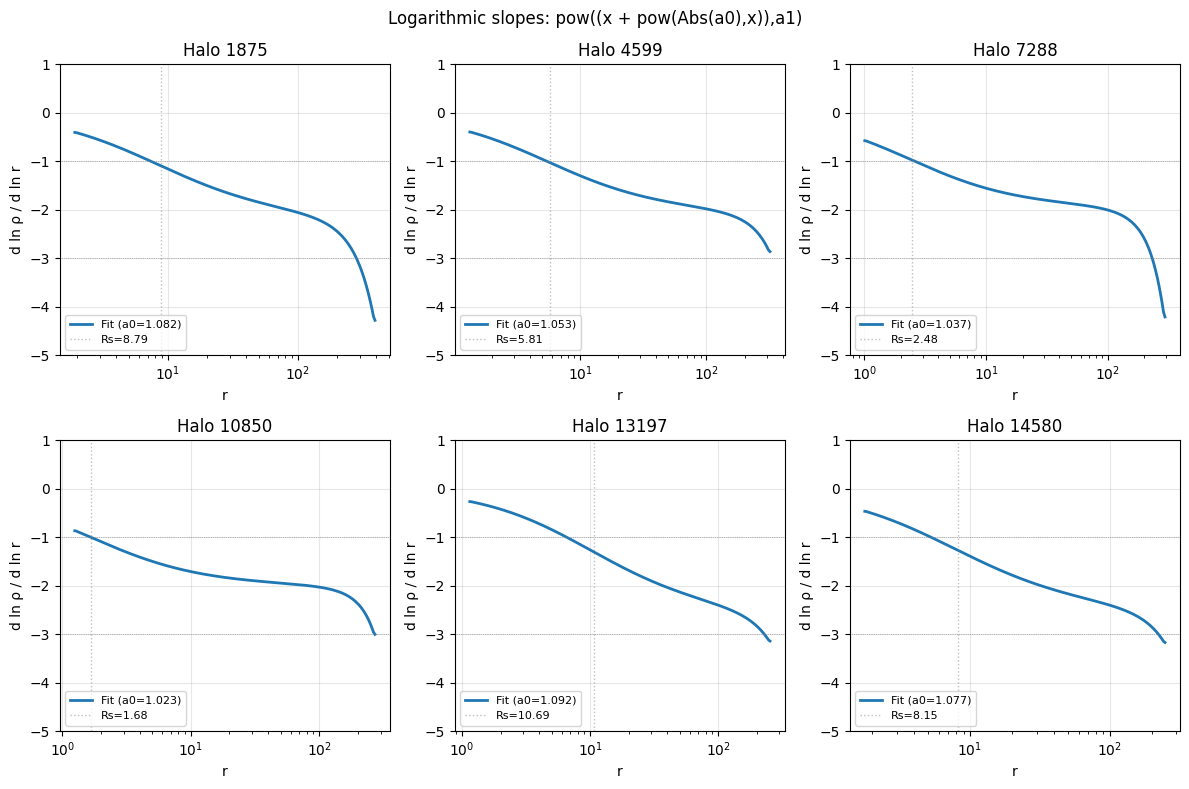

In [9]:
# Plot density profiles and logarithmic slopes in physical units (6 halos)
valid_results = [r for r in results if r['params'] is not None]
valid_indices = [i for i, r in enumerate(results) if r['params'] is not None]

# Select 6 halos evenly spaced
n_plot = 6
plot_indices = [valid_indices[(i + 1) * (len(valid_indices) // (n_plot + 1))] for i in range(n_plot)]

# Figure 1: Density profiles (2x3)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, idx in enumerate(plot_indices):
    ax = axes[i]
    res = results[idx]
    halo_id = res['halo_id']

    # Raw particle radii
    radii = halos[halo_id]
    rmin, rmax = radii.min(), radii.max()

    # Fitted parameters
    Rs = res['params'][0]
    a0 = res['params'][1] if fitter.nfree >= 1 else None

    # Estimate density from particles using binned data
    bin_pos = binned['bin_positions'][idx]
    bin_counts = binned['bin_counts'][idx]

    # Compute shell volumes: V = 4/3 * pi * (r_out^3 - r_in^3)
    # Use bin edges (geometric mean for log bins)
    bin_edges = np.zeros(len(bin_pos) + 1)
    bin_edges[1:-1] = np.sqrt(bin_pos[:-1] * bin_pos[1:])
    bin_edges[0] = bin_pos[0]**2 / bin_edges[1]  # extrapolate
    bin_edges[-1] = bin_pos[-1]**2 / bin_edges[-2]  # extrapolate

    shell_volumes = 4/3 * np.pi * (bin_edges[1:]**3 - bin_edges[:-1]**3)
    rho_data = bin_counts / shell_volumes

    # Physical radii for model plotting
    r = np.logspace(np.log10(rmin), np.log10(rmax), 200)

    # Compute fitted density
    rho_fit = rho_func(r, *res['params'])

    # Normalize both to integrate to unity: int rho * 4*pi*r^2 dr = 1
    # For data: sum(rho_data * shell_volumes) = total particles
    norm_data = np.sum(rho_data * shell_volumes)
    rho_data_norm = rho_data / norm_data

    # For fit: integrate rho_fit * 4*pi*r^2 dr
    integrand = rho_fit * 4 * np.pi * r**2
    norm_fit = np.trapezoid(integrand, r)
    rho_fit_norm = rho_fit / norm_fit

    ax.loglog(bin_pos, rho_data_norm, 'k.', ms=3, alpha=0.5, label='Data')
    ax.loglog(r, rho_fit_norm, 'C0-', lw=2, label='Fit')
    ax.axvline(Rs, color='gray', ls=':', lw=1, alpha=0.5)

    ax.set_xlabel('r')
    ax.set_ylabel('ρ(r) [normalized]')
    ax.set_title(f'Halo {halo_id}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Density profiles: {expr}', fontsize=12)
plt.tight_layout()
plt.show()

# Figure 2: Logarithmic slopes (2x3)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, idx in enumerate(plot_indices):
    ax = axes[i]
    res = results[idx]
    halo_id = res['halo_id']

    # Raw particle radii
    radii = halos[halo_id]
    rmin, rmax = radii.min(), radii.max()

    # Fitted parameters
    Rs = res['params'][0]
    a0 = res['params'][1] if fitter.nfree >= 1 else 0

    # Physical radii for model plotting
    r = np.logspace(np.log10(rmin), np.log10(rmax), 200)

    # Compute fitted density and its logarithmic slope numerically
    rho_fit = rho_func(r, *res['params'])
    log_r = np.log(r)
    log_rho = np.log(rho_fit)
    slope_fit = np.gradient(log_rho, log_r)

    ax.semilogx(r, slope_fit, 'C0-', lw=2, label=f'Fit (a0={a0:.3f})')
    ax.axvline(Rs, color='gray', ls=':', lw=1, alpha=0.5, label=f'Rs={Rs:.2f}')
    ax.axhline(-1, color='gray', ls=':', lw=0.5)
    ax.axhline(-3, color='gray', ls=':', lw=0.5)

    ax.set_xlabel('r')
    ax.set_ylabel('d ln ρ / d ln r')
    ax.set_title(f'Halo {halo_id}')
    ax.set_ylim(-5, 1)
    ax.legend(fontsize=8, loc='lower left')
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Logarithmic slopes: {expr}', fontsize=12)
plt.tight_layout()
plt.show()

## Nested Optimization

In [20]:
# nested_expr = "1/(x*(1+x)**a0)"
# nested_expr = "pow(x,(-pow(x,a0)))"
nested_expr = "pow(x,(-pow(x,(a0))))"
print(f"Expression: {nested_expr}")

# Compile the nested fitter
nested_fitter = cdmprof.compile_nested_fitter(nested_expr)
print(f"Compiled nested fitter with {nested_fitter.nparams} parameters")

Expression: pow(x,(-pow(x,(a0))))
Compiled nested fitter with 2 parameters


In [21]:
# Run nested optimization
# param_is_global: [Rs, a0] -> [False, True] means a0 is global
param_is_global = [False, True]  # Rs=local, a0=global

print("Running nested optimization...")
print(f"  Global params: a0 (outer slope)")
print(f"  Local params: Rs (scale radius per halo)")

nested_result = nested_fitter.fit(
    binned,
    param_is_global=param_is_global,
    Rs_upper_factor=10,
    a_lower=-10,
    a_upper=10,
    inner_max_restarts=1000,
    outer_max_restarts=100,
    inner_maxeval=1000,
    outer_maxeval=1000,
    verbose=True,
    nthreads=8
)

# Compute average loss per particle
npart = binned['npart']
loss_per_particle = nested_result['halo_losses'] / npart
avg_loss_per_particle = np.mean(loss_per_particle)

print(f"\nResults:")
print(f"  Converged: {nested_result['converged']}")
print(f"  Global params ({nested_result['global_param_names']}): {nested_result['global_params']}")
print(f"  Total loss: {nested_result['total_loss']:.2f}")
print(f"  Average loss per particle: {avg_loss_per_particle:.4f}")
print(f"  Outer evaluations: {nested_result['outer_neval']}")
print(f"  Total inner evaluations: {nested_result['total_inner_neval']}")

Running nested optimization...
  Global params: a0 (outer slope)
  Local params: Rs (scale radius per halo)
Outer restart 1/100
  Outer eval 1: global = [0.000000]
    Halo 0: loss=1.797693e+308, rmin=1.1914, rmax=660.6521
  Outer eval 2: global = [5.000000]
    Halo 0: loss=1.797693e+308, rmin=1.1914, rmax=660.6521
Outer restart 2/100
  Outer eval 1: global = [-7.781915]
    Halo 0: loss=1.797693e+308, rmin=1.1914, rmax=660.6521
  Outer eval 2: global = [-6.118351]
    Halo 0: loss=1.797693e+308, rmin=1.1914, rmax=660.6521
Outer restart 3/100
  Outer eval 1: global = [4.159368]
    Halo 0: loss=1.797693e+308, rmin=1.1914, rmax=660.6521
  Outer eval 2: global = [9.159368]
    Halo 0: loss=1.797693e+308, rmin=1.1914, rmax=660.6521
Outer restart 4/100
  Outer eval 1: global = [-3.899960]
    Halo 0: loss=1.797693e+308, rmin=1.1914, rmax=660.6521
  Outer eval 2: global = [1.100040]
    Halo 0: loss=1.797693e+308, rmin=1.1914, rmax=660.6521
Outer restart 5/100
  Outer eval 1: global = [8.0

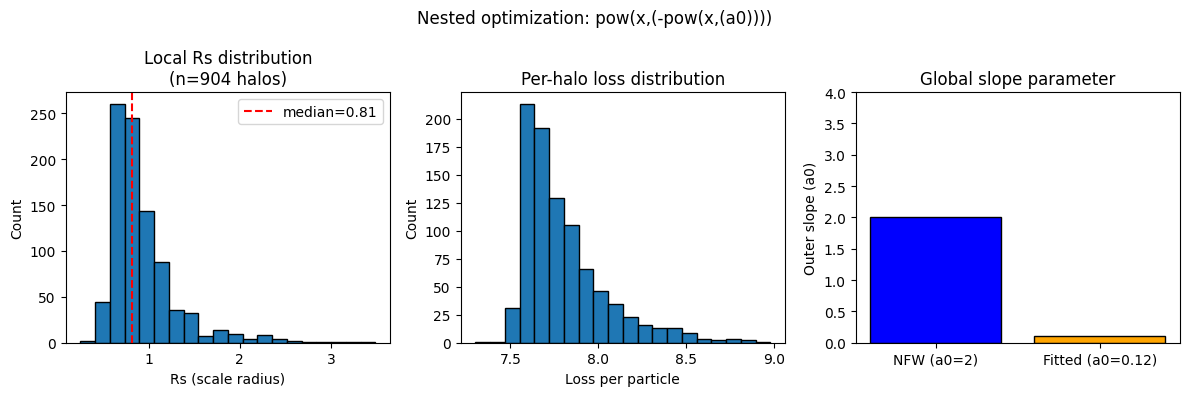


The fitted global outer slope a0=0.115
(NFW has a0=2, Hernquist has a0=3)


In [22]:
# Visualize nested optimization results
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 1. Distribution of local Rs values
ax = axes[0]
local_Rs = nested_result['local_params'][:, 0]
ax.hist(local_Rs, bins=20, edgecolor='black')
ax.set_xlabel('Rs (scale radius)')
ax.set_ylabel('Count')
ax.set_title(f'Local Rs distribution\n(n={halos.n_halos} halos)')
ax.axvline(np.median(local_Rs), color='r', ls='--', label=f'median={np.median(local_Rs):.2f}')
ax.legend()

# 2. Per-halo losses
ax = axes[1]
ax.hist(nested_result['halo_losses'] / binned['npart'], bins=20, edgecolor='black')
ax.set_xlabel('Loss per particle')
ax.set_ylabel('Count')
ax.set_title('Per-halo loss distribution')

# 3. Compare with standard NFW (a0=2)
ax = axes[2]
global_a0 = nested_result['global_params'][0]
ax.bar(['NFW (a0=2)', f'Fitted (a0={global_a0:.2f})'], 
       [2.0, global_a0], color=['blue', 'orange'], edgecolor='black')
ax.set_ylabel('Outer slope (a0)')
ax.set_title('Global slope parameter')
ax.set_ylim(0, 4)

plt.suptitle(f"Nested optimization: {nested_expr}", fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nThe fitted global outer slope a0={global_a0:.3f}")
print(f"(NFW has a0=2, Hernquist has a0=3)")